<a href="https://colab.research.google.com/github/gaetan311/mini_projet/blob/main/MALL_CUSTOMERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

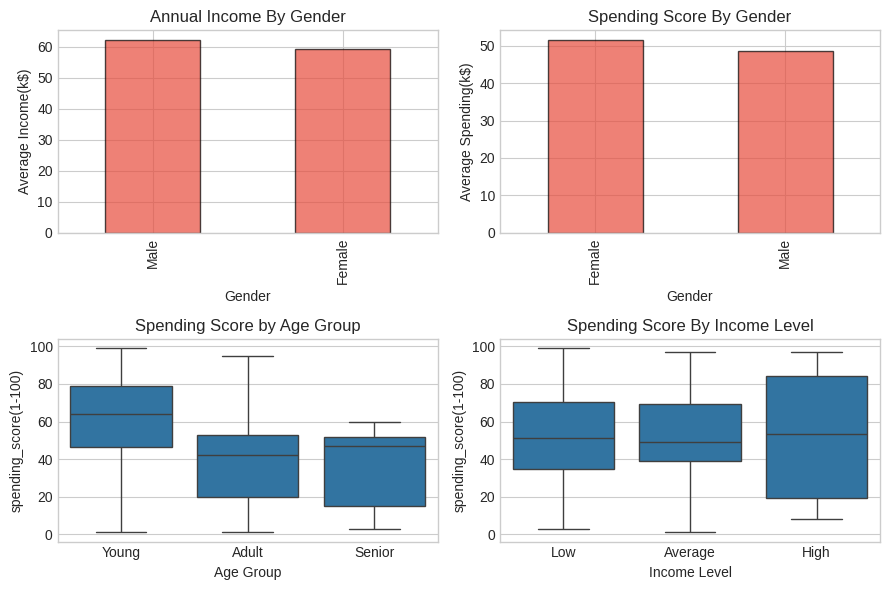

In [2]:
import pandas as pd
#import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("Mall_Customers.csv")
df.rename(columns={'Annual Income (k$)': 'annual_income(k$)', 'Spending Score (1-100)':'spending_score(1-100)'}, inplace=True)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['annual_income(k$)'] = pd.to_numeric(df['annual_income(k$)'], errors='coerce')
df = df.dropna(subset=['Age', 'annual_income(k$)'])

bins_age = [df['Age'].min() - 1, 35, 55, df['Age'].max() + 1]
labels_age = ['Young', 'Adult', 'Senior']
bins_income = [df['annual_income(k$)'].min() - 1, 50, 90, df['annual_income(k$)'].max() + 1]
labels_income = ['Low', 'Average', 'High']

df['Age_group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, include_lowest=True)
df['Income_level'] = pd.cut(df['annual_income(k$)'], bins=bins_income, labels=labels_income, include_lowest=True)

df.drop(columns=['CustomerID'], inplace=True)

gender_income = df.groupby('Gender')['annual_income(k$)'].mean().sort_values(ascending=False)
gender_spending = df.groupby('Gender')['spending_score(1-100)'].mean().sort_values(ascending=False)
group_spending = df.groupby('Age_group', observed=False)['spending_score(1-100)'].mean().sort_values(ascending=False)
income_spending = df.groupby('Income_level', observed=False)['spending_score(1-100)'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(2,2,figsize=(9,6))
ax = ax.flatten()

gender_income.plot(kind='bar', ax=ax[0], color='#e74c3c', edgecolor='black',alpha=0.7)
ax[0].set_title('Annual Income By Gender')
ax[0].set_ylabel('Average Income(k$)')
ax[0].set_xlabel('Gender')

gender_spending.plot(kind='bar', ax=ax[1], color='#e74c3c', edgecolor='black',alpha=0.7)
ax[1].set_title('Spending Score By Gender')
ax[1].set_ylabel('Average Spending(k$)')
ax[1].set_xlabel('Gender')


sns.boxplot(x='Age_group', y='spending_score(1-100)', data=df, ax=ax[2])
ax[2].set_title('Spending Score by Age Group')
ax[2].set_xlabel('Age Group')

sns.boxplot(x='Income_level', y='spending_score(1-100)', data=df, ax=ax[3])
ax[3].set_title('Spending Score By Income Level')
ax[3].set_xlabel('Income Level')

plt.tight_layout()
plt.show()

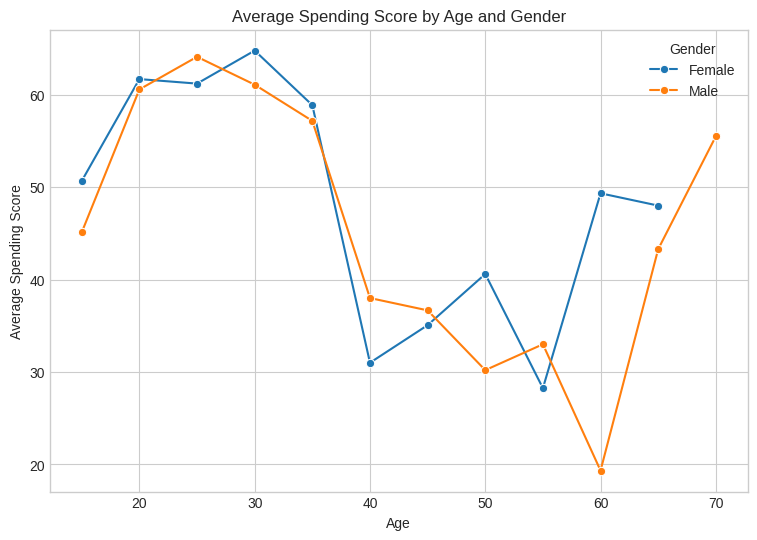

In [3]:
df['Age_bin_5'] = (df['Age'] // 5) * 5
age_spending_5 = df.groupby(['Age_bin_5', 'Gender'])['spending_score(1-100)'].mean().reset_index()
plt.figure(figsize=(9, 6))
sns.lineplot(x='Age_bin_5', y='spending_score(1-100)', data=age_spending_5, hue='Gender', marker='o')
plt.title('Average Spending Score by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Average Spending Score')
plt.legend(title='Gender')
plt.show()

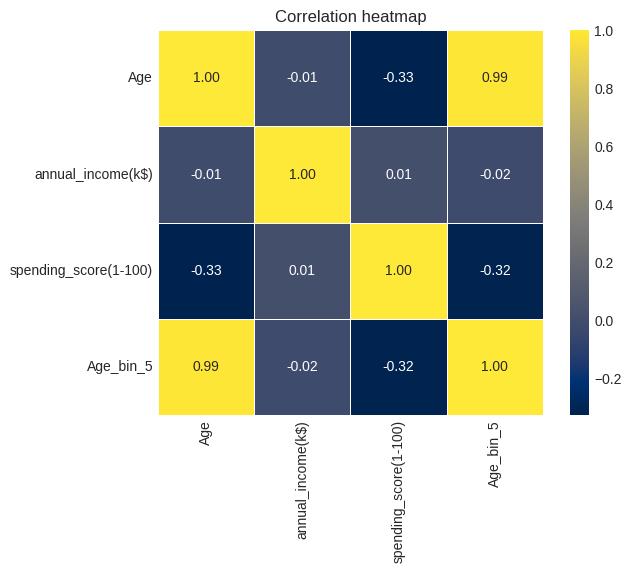

In [4]:
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='cividis', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation heatmap')
plt.show()

/tmp/ipykernel_3592/2651442787.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(df, values='spending_score(1-100)', index='Age_group', columns='Income_level', aggfunc='mean')


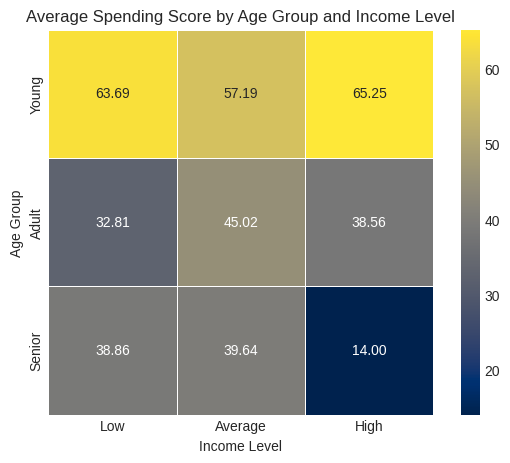

In [5]:
pivot_table = pd.pivot_table(df, values='spending_score(1-100)', index='Age_group', columns='Income_level', aggfunc='mean')
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table, annot=True, cmap='cividis', fmt='.2f', square=True, linewidths=0.5)
plt.title('Average Spending Score by Age Group and Income Level')
plt.xlabel('Income Level')
plt.ylabel('Age Group')
plt.show()

In [6]:
top_spenders = df[df['spending_score(1-100)']>80].sort_values(by='spending_score(1-100)', ascending=False)
print("Number of Whales:" ,len(top_spenders))
top_spenders.head(10)



Number of Whales: 30


,Gender,Age,annual_income(k$),spending_score(1-100),Age_group,Income_level,Age_bin_5
11,Female,35,19,99,Young,Low,35
19,Female,35,23,98,Young,Low,35
185,Male,30,99,97,Young,High,30
145,Male,28,77,97,Young,Average,25
127,Male,40,71,95,Adult,Average,40
167,Female,33,86,95,Young,Average,30
7,Female,23,18,94,Young,Low,20
163,Female,31,81,93,Young,Average,30
141,Male,32,75,93,Young,Average,30
173,Male,36,87,92,Adult,Average,35


In [7]:
display(top_spenders[['Age', 'annual_income(k$)']].describe().loc[['mean', 'min', 'max']])

,Age,annual_income(k$)
mean,30.6,69.066667
min,18.0,15.000000
max,40.0,137.000000


In [8]:
print('Gender Distribution \n' , top_spenders['Gender'].value_counts())

Gender Distribution 
 Gender
Female    16
Male      14
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
X = df[['spending_score(1-100)', 'annual_income(k$)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,spending_score(1-100),annual_income(k$)
0,-0.434801,-1.738999
1,1.195704,-1.738999
2,-1.715913,-1.700830
3,1.040418,-1.700830
4,-0.395980,-1.662660


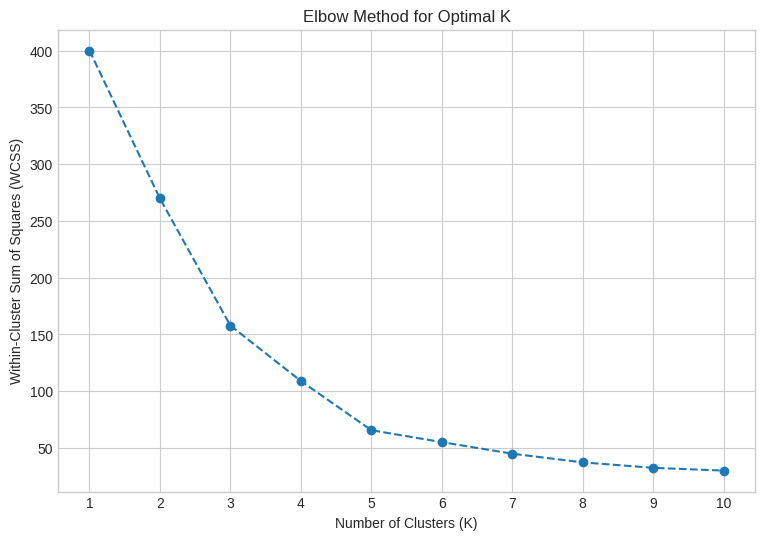

In [10]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

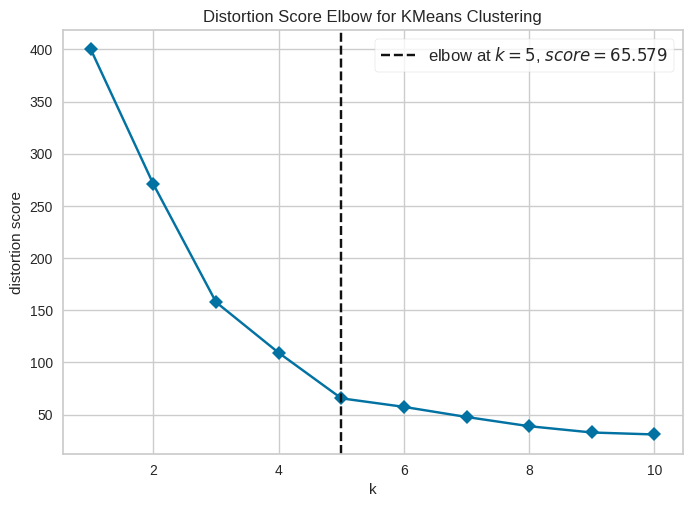

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [11]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(X_scaled_df)
visualizer.show()

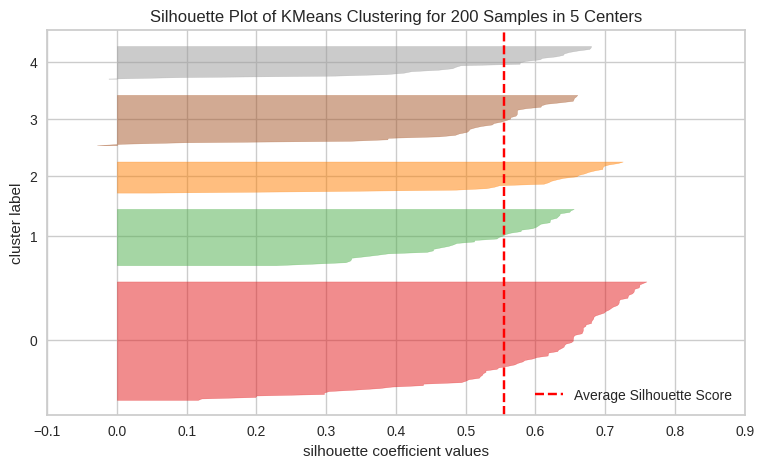

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [15]:
plt.figure(figsize=(9,5))
model_5 = KMeans(n_clusters=5, random_state=42)
visualizer = SilhouetteVisualizer(model_5)
visualizer.fit(X_scaled_df)
visualizer.show()

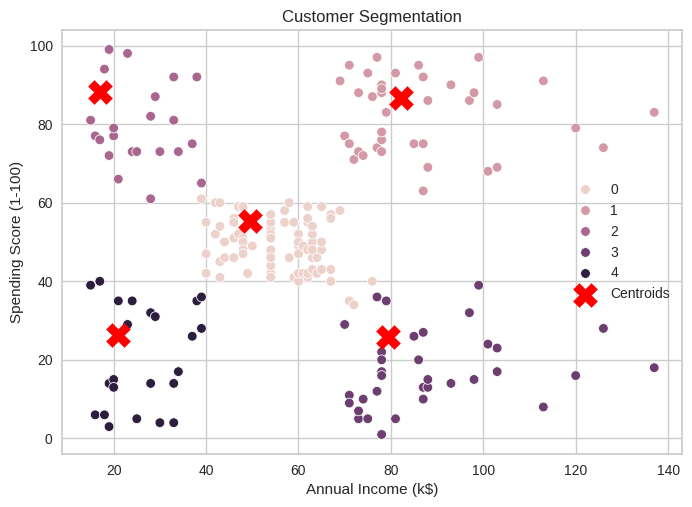

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42, init='k-means++')
df['cluster'] = kmeans.fit_predict(X_scaled_df)
sns.scatterplot(x='annual_income(k$)', y='spending_score(1-100)', hue='cluster', data=df)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=300, c='red', label='Centroids')
plt.legend()
plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [23]:
profile = df.groupby('cluster')[['Age', 'spending_score(1-100)', 'annual_income(k$)']].mean().round(1)
profile['Count'] = df.groupby('cluster')['cluster'].count()
profile.index.name = 'Cluster'
profile


,Age,spending_score(1-100),annual_income(k$),Count
Cluster,,,,
0,42.7,49.5,55.3,81
1,32.7,82.1,86.5,39
2,25.3,79.4,25.7,22
3,41.1,17.1,88.2,35
4,45.2,20.9,26.3,23


In [19]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=['annual_income(k$)', 'spending_score(1-100)'])
centroids_df['ClusterID'] = range(1, len(centroids_df) + 1)
centroids_df.index.name = 'ClusterID'
def get_cluster_label(row):
    if row['annual_income(k$)'] > 70 and row['spending_score(1-100)'] > 60:
      return 'VIPs(High income, high spending)'
    elif row['annual_income(k$)'] > 70 and row['spending_score(1-100)'] < 40:
      return 'Target(High income, low spending)'
    elif row['annual_income(k$)'] < 70 and row['spending_score(1-100)'] > 60:
      return 'Spenders(Low income, high spending)'
    elif row['annual_income(k$)'] < 70 and row['spending_score(1-100)'] < 40:
      return 'Normal(Low income, low spending)'
    else:
      return 'Average(Middle Class)'
centroids_df['ClusterLabel'] = centroids_df.apply(get_cluster_label, axis=1)
centroids_df

,annual_income(k$),spending_score(1-100),ClusterID,ClusterLabel
ClusterID,,,,
0,9.583333,24.583333,1,"Normal(Low income, low spending)"
1,46.162791,63.720930,2,"Spenders(Low income, high spending)"
2,82.172414,78.551724,3,"VIPs(High income, high spending)"
3,22.000000,109.700000,4,"Spenders(Low income, high spending)"
4,74.600000,24.466667,5,"Target(High income, low spending)"
5,82.000000,109.700000,6,"VIPs(High income, high spending)"
6,12.681818,80.181818,7,"Spenders(Low income, high spending)"
7,34.615385,30.000000,8,"Normal(Low income, low spending)"
8,52.675000,48.100000,9,Average(Middle Class)


In [24]:
cluster_map = dict(zip(centroids_df['ClusterID'], centroids_df['ClusterLabel']))
df['Cluster_name'] = df['cluster'].map(cluster_map)
df.head()

,Gender,Age,annual_income(k$),spending_score(1-100),Age_group,Income_level,Age_bin_5,cluster,Cluster_name
0,Male,19,15,39,Young,Low,15,4,"Spenders(Low income, high spending)"
1,Male,21,15,81,Young,Low,20,2,"Spenders(Low income, high spending)"
2,Female,20,16,6,Young,Low,20,4,"Spenders(Low income, high spending)"
3,Female,23,16,77,Young,Low,20,2,"Spenders(Low income, high spending)"
4,Female,31,17,40,Young,Low,30,4,"Spenders(Low income, high spending)"


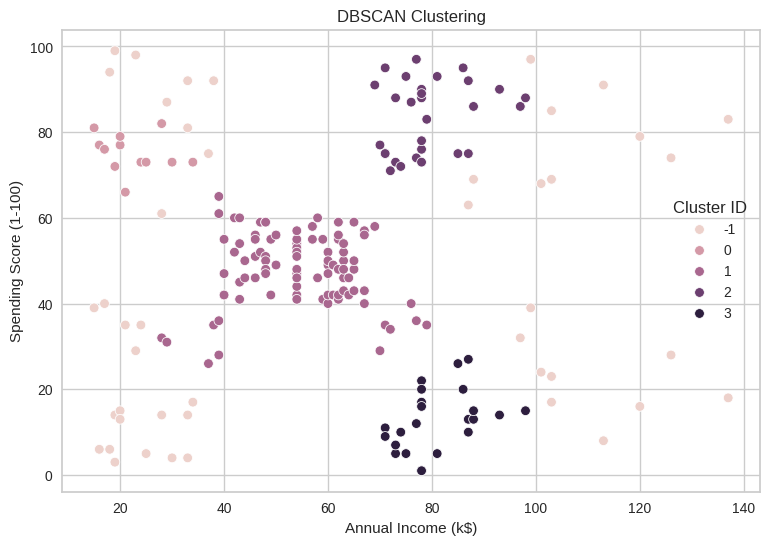

In [30]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=9)
df['DBSCAN_cluster'] = dbscan.fit_predict(X_scaled_df)
plt.figure(figsize=(9, 6))
sns.scatterplot(x='annual_income(k$)', y='spending_score(1-100)', hue='DBSCAN_cluster', data=df)
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster ID')
plt.show()

In [31]:
n_noise = list(df['DBSCAN_cluster']).count(-1)
print('Number of noise points:', n_noise)

Number of noise points: 45


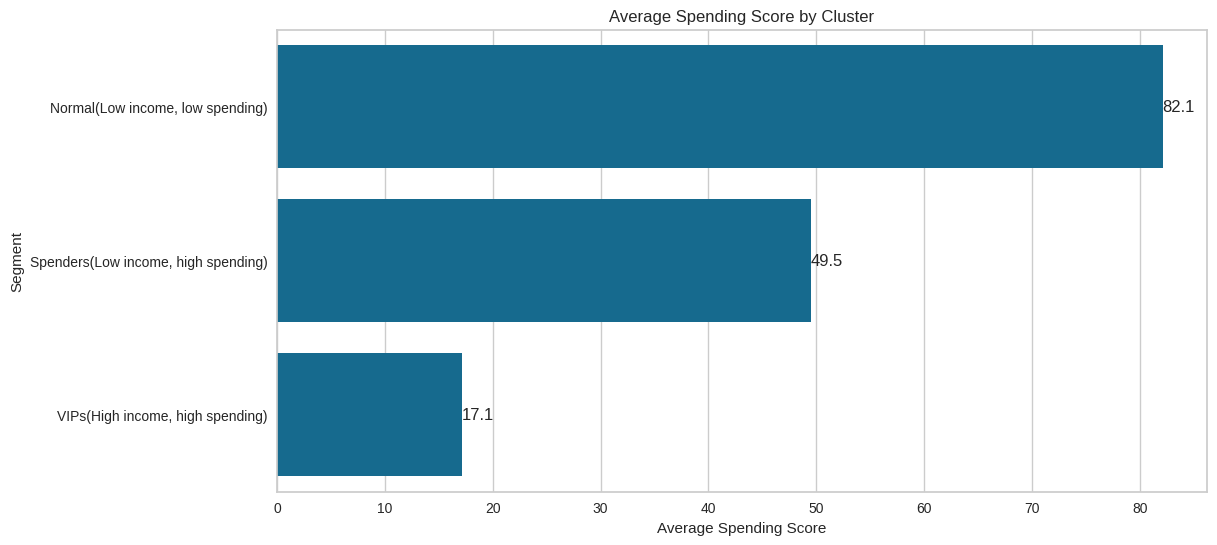

In [37]:
avg_spending = df.groupby('Cluster_name')['spending_score(1-100)'].mean().sort_values(ascending=False)
avg_income = df.groupby('Cluster_name')['annual_income(k$)'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_spending.values, y=avg_spending.index)
plt.title('Average Spending Score by Cluster')
plt.xlabel('Average Spending Score')
plt.ylabel('Segment')
for index, value in enumerate(avg_spending.values):
    plt.text(value, index, str(round(value, 1)), ha='left', va='center')
plt.show()
